## _import libraries_

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## _load Dataset_

In [2]:
movies  = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
print("ratings shape:", ratings.shape)
print("movies  shape:", movies.shape)
movies.head(10)


ratings shape: (100836, 4)
movies  shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [3]:
ratings.sample(5)

,userId,movieId,rating,timestamp
43871,292,88744,3.5,1324817870
44775,298,3996,3.0,1447598098
37073,249,80166,3.0,1430483065
44089,294,1020,4.0,966595748
55509,368,1037,3.0,971277081


In [4]:
movies.sample(5)

,movieId,title,genres
9484,169982,Power Rangers (2017),Action|Adventure|Sci-Fi
3867,5437,"Manhattan Project, The (1986)",Comedy|Sci-Fi|Thriller
4987,7698,"China Syndrome, The (1979)",Drama|Thriller
6663,57326,In the Name of the King: A Dungeon Siege Tale ...,Action|Adventure|Fantasy
6964,66090,Eden Lake (2008),Horror|Thriller


In [5]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [6]:
print(movies.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None


In [7]:
print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


## _cleaning Data_

In [8]:
ratings.describe().style.background_gradient(cmap='coolwarm')

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836.000000
mean,326.127564,19435.295718,3.501557,1205946087.368469
std,182.618491,35530.987199,1.042529,216261035.995132
min,1.000000,1.000000,0.500000,828124615.000000
25%,177.000000,1199.000000,3.000000,1019123866.000000
50%,325.000000,2991.000000,3.500000,1186086662.000000
75%,477.000000,8122.000000,4.000000,1435994144.500000
max,610.000000,193609.000000,5.000000,1537799250.000000


In [9]:
print(movies.isnull().sum())
print(ratings.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [10]:
print(movies.duplicated().sum())
print(ratings.duplicated().sum())


0
0


In [11]:
ratings.drop(columns=['timestamp'], inplace=True)

In [12]:
#  Clean Text (Genres)
def cleangenres(text):
    text = str(text).lower()
    text = text.replace('|', ' ')
    text = re.sub(r'[^a-z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

movies['genres'] = movies['genres'].apply(cleangenres)

In [13]:
merged = pd.merge(ratings, movies, on="movieId")
merged.head(10)

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),adventure animation children comedy fantasy
1,1,3,4.0,Grumpier Old Men (1995),comedy romance
2,1,6,4.0,Heat (1995),action crime thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),mystery thriller
4,1,50,5.0,"Usual Suspects, The (1995)",crime mystery thriller
5,1,70,3.0,From Dusk Till Dawn (1996),action comedy horror thriller
6,1,101,5.0,Bottle Rocket (1996),adventure comedy crime romance
7,1,110,4.0,Braveheart (1995),action drama war
8,1,151,5.0,Rob Roy (1995),action drama romance war
9,1,157,5.0,Canadian Bacon (1995),comedy war


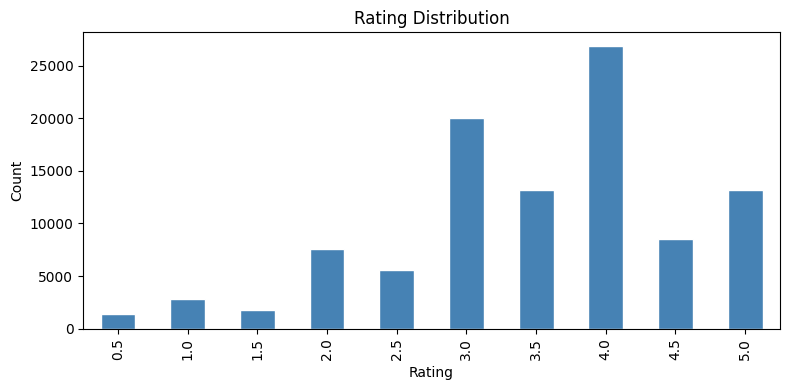

In [14]:
# Rating Distribution
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

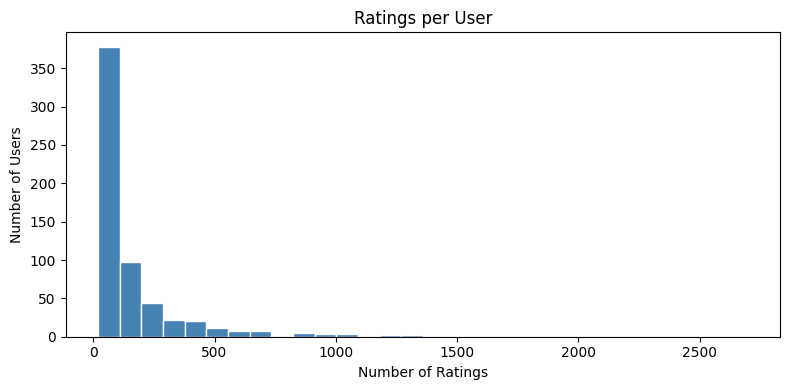

show number of each value in ratings per user col
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


In [15]:


# show number of ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_user, bins=30, color='steelblue', edgecolor='white')
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

print("show number of each value in ratings per user col")
print(ratings_per_user.describe())


## Collaborative Filtering

In [16]:
#prepeare data for surprise
# constrains
reader = Reader(rating_scale=(1, 5))
#user item matrix
data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)
print("Done")

Done


In [17]:
# split data 80% train - 20% test
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [18]:
# train SVD model
#model Hyperparameter Tuning
Model=SVD(n_factors=50,n_epochs=20, random_state=42)
Model.fit(trainset)

In [19]:

# predict and evaluate model
predictions=Model.test(testset)


rmse =accuracy.rmse((predictions))
mae =accuracy.mae((predictions))

RMSE: 0.8775
MAE:  0.6742


In [20]:
def recommend_cf(user_id, n=10): 
    # all movies
    all_movie_ids = ratings['movieId'].unique()

    # movies user already watched
    watched =[]
    for index,row in ratings.iterrows():
        if row['userId']==user_id:
            watched.append(row['movieId'])

    # movies user haven't watched yet
    not_watched = []
    for m in all_movie_ids:
        if m not in watched:
            not_watched.append(m)

    # predict rating for each movie
    predictions_list = []
    for movie_id in not_watched:
        pred = Model.predict(user_id, movie_id)
        predictions_list.append((movie_id, pred.est))

    # sort from highest to lowest
    pred_df = pd.DataFrame(predictions_list, columns=['movieId', 'score'])
    top_pred_df = pred_df.sort_values(by='score', ascending=False).head(n)

    result = []
    for index, row  in top_pred_df.iterrows():

       movie_info = movies[movies['movieId'] == row['movieId']]

       title = movie_info['title'].values[0]
       genres = movie_info['genres'].values[0]

       result.append({
        'title': title,
        'genres': genres,
        'predicted_rating': f"{row['score']:.2f}"
        })

    return pd.DataFrame(result)


In [21]:
# show top 10 movies for user 1
recommendations=recommend_cf(user_id=1,n=10)
print("top Movie Recommendations :")
print(recommendations)

top Movie Recommendations :
                                               title  \
0                   Shawshank Redemption, The (1994)   
1         Ghost in the Shell (Kôkaku kidôtai) (1995)   
2                         Kiss Kiss Bang Bang (2005)   
3                        Boondock Saints, The (2000)   
4                          Lawrence of Arabia (1962)   
5                             Rosemary's Baby (1968)   
6         Life Is Beautiful (La Vita è bella) (1997)   
7     Cinema Paradiso (Nuovo cinema Paradiso) (1989)   
8  Amelie (Fabuleux destin d'Amélie Poulain, Le) ...   
9                               Departed, The (2006)   

                          genres predicted_rating  
0                    crime drama             5.00  
1               animation sci fi             5.00  
2  comedy crime mystery thriller             5.00  
3    action crime drama thriller             5.00  
4            adventure drama war             5.00  
5          drama horror thriller           

# Content-Based Filtering

In [22]:
# Check Dataset
print(ratings.shape)
print(movies[['movieId', 'title', 'genres']].head())

(100836, 3)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  adventure animation children comedy fantasy  
1                   adventure children fantasy  
2                               comedy romance  
3                         comedy drama romance  
4                                       comedy  


In [23]:
# Remove Duplicate Movies
movies_content = movies[['movieId', 'title', 'genres']].drop_duplicates()
movies_content.reset_index(drop=True, inplace=True)
movies_content.head()

,movieId,title,genres
0,1,Toy Story (1995),adventure animation children comedy fantasy
1,2,Jumanji (1995),adventure children fantasy
2,3,Grumpier Old Men (1995),comedy romance
3,4,Waiting to Exhale (1995),comedy drama romance
4,5,Father of the Bride Part II (1995),comedy


In [24]:
# Handle Missing Values
movies_content['genres'] = movies_content['genres'].fillna('')

In [25]:
# Convert Genres to TF-IDF Matrix

# 1. Combine title + genres to create richer content for comparison
movies_content['metadata'] = movies_content['title'] + " " + movies_content['genres']

# 2. Use ngram_range=(1,2) to include both single words and bigrams for better accuracy
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

# 3. Transform the new metadata column instead of genres only
genre_matrix = tfidf.fit_transform(movies_content['metadata'])

# 4. Print new matrix shape (more columns due to titles + bigrams)
print(genre_matrix.shape)


(9742, 30747)


In [26]:
#Calculate Cosine Similarity
cosine_sim = cosine_similarity(genre_matrix, genre_matrix)
print(cosine_sim.shape)

(9742, 9742)


In [27]:
# Create Movie Index Mapping
indices = pd.Series(movies_content.index,index=movies_content['title']).drop_duplicates()
indices.head()

title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
dtype: int64

In [28]:
# Recommendation Function
def recommend_cb(title, cosine_sim=cosine_sim):
    # Check if movie exists
    if title not in indices:
        return "Movie not found"
    # Get movie index
    idx = indices[title]
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Sort movies
    sim_scores = sorted(sim_scores,key=lambda x: x[1],reverse=True)
    # Remove selected movie
    sim_scores = sim_scores[1:11]
    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]
    # Return recommendations
    return movies_content[['title', 'genres']].iloc[movie_indices]

In [29]:
# Test Recommendation System
recommend_cb('Toy Story (1995)')

,title,genres
2355,Toy Story 2 (1999),adventure animation children comedy fantasy
7355,Toy Story 3 (2010),adventure animation children comedy fantasy imax
12,Balto (1995),adventure animation children
6194,"Wild, The (2006)",adventure animation children comedy fantasy
3568,"Monsters, Inc. (2001)",adventure animation children comedy fantasy
6486,Shrek the Third (2007),adventure animation children comedy fantasy
8219,Turbo (2013),adventure animation children comedy fantasy
1706,Antz (1998),adventure animation children comedy fantasy
9430,Moana (2016),adventure animation children comedy fantasy
8806,Home (2015),adventure animation children comedy fantasy sc...


In [30]:
# Test Another Movie
recommend_cb('Jumanji (1995)')

,title,genres
53,"Indian in the Cupboard, The (1995)",adventure children fantasy
131,Casper (1995),adventure children
1565,Tall Tale (1995),adventure children fantasy western
4439,Born to Be Wild (1995),adventure children comedy drama
7,Tom and Huck (1995),adventure children
119,"Amazing Panda Adventure, The (1995)",adventure children
9636,Jumanji: Welcome to the Jungle (2017),action adventure children
12,Balto (1995),adventure animation children
7108,G-Force (2009),action adventure children fantasy
8800,Pan (2015),adventure children fantasy


In [31]:
#Recommendation Function with Similarity Score
def recommend_with_score(title, cosine_sim=cosine_sim):

    if title not in indices:
        return "Movie not found"

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    scores = [i[1] for i in sim_scores]

    result = movies_content[['title', 'genres']].iloc[movie_indices]

    result['similarity_score'] = scores

    return result

In [32]:
# Test Function with Scores
recommend_with_score('Heat (1995)')

,title,genres,similarity_score
22,Assassins (1995),action crime thriller,0.454550
156,"Net, The (1995)",action crime thriller,0.442344
142,Hackers (1995),action adventure crime thriller,0.346281
2815,F/X (1986),action crime thriller,0.345086
138,Die Hard: With a Vengeance (1995),action crime thriller,0.334612
341,Bad Company (1995),action crime drama,0.296607
2194,Body Heat (1981),crime thriller,0.295784
70,"Crossing Guard, The (1995)",action crime drama thriller,0.288840
8204,"Heat, The (2013)",action comedy crime,0.288076
38,Dead Presidents (1995),action crime drama,0.286527


## Hybrid Recommendation (CF + CB)

In [33]:
def recommend_hybrid(user_id, title, n=10, cf_weight=0.6, cb_weight=0.4):
    all_movies  = ratings['movieId'].unique()
    watched     = ratings[ratings['userId'] == user_id]['movieId'].values
    not_watched = [m for m in all_movies if m not in watched]

    # CF scores (normalize 0 to 1)
    cf_scores = {m: Model.predict(user_id, m).est for m in not_watched}
    cf_min, cf_max = min(cf_scores.values()), max(cf_scores.values())
    cf_norm = {m: (s - cf_min) / (cf_max - cf_min + 1e-9) for m, s in cf_scores.items()}

    # CB scores (normalize 0 to 1)
    cb_scores = {}
    if title in indices:
        idx = indices[title]
        for i, score in enumerate(cosine_sim[idx]):
            movie_id = movies_content.iloc[i]['movieId']
            if movie_id in cf_norm:
                cb_scores[movie_id] = score

    cb_vals = list(cb_scores.values()) if cb_scores else [0]
    cb_min, cb_max = min(cb_vals), max(cb_vals)
    cb_norm = {m: (s - cb_min) / (cb_max - cb_min + 1e-9) for m, s in cb_scores.items()}

    # combine scores
    hybrid_scores = {
        m: cf_weight * cf_norm[m] + cb_weight * cb_norm.get(m, 0)
        for m in cf_norm
    }

    top = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    result = []
    for movie_id, score in top:
        info = movies[movies['movieId'] == movie_id]
        if len(info) == 0:
            continue
        result.append({
            'title':         info['title'].values[0],
            'genres':        info['genres'].values[0],
            'hybrid_score':  round(score, 4)
        })

    return pd.DataFrame(result)

# test
print(recommend_hybrid(user_id=1, title='Toy Story (1995)', n=10))


                                               title  \
0                                 Toy Story 3 (2010)   
1                                 Toy Story 2 (1999)   
2                                          Up (2009)   
3                                       Shrek (2001)   
4    Grand Day Out with Wallace and Gromit, A (1989)   
5                                     Tangled (2010)   
6                                Finding Nemo (2003)   
7                              Monsters, Inc. (2001)   
8  City of Lost Children, The (Cité des enfants p...   
9             Wallace & Gromit: A Close Shave (1995)   

                                              genres  hybrid_score  
0   adventure animation children comedy fantasy imax        0.9365  
1        adventure animation children comedy fantasy        0.9079  
2                 adventure animation children drama        0.7387  
3  adventure animation children comedy fantasy ro...        0.7134  
4         adventure animation children

## Evaluation (Precision, Recall, F1)


In [34]:
def precision__recall__f1(predictions, k=10, threshold=3.0):
    df = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])

    precisions, recalls = [], []

    for uid in df['uid'].unique():
        user_df = df[df['uid'] == uid].sort_values('est', ascending=False)
        top_k   = user_df.head(k)

        n_rel = (user_df['rui'] >= threshold).sum()
        n_hit = (top_k['rui']   >= threshold).sum()

        precisions.append(n_hit / k)
        recalls.append(n_hit / n_rel if n_rel > 0 else 0)

    p  = np.mean(precisions)
    r  = np.mean(recalls)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

    return p, r, f1

In [35]:
p, r, f1 = precision__recall__f1(predictions)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Precision (Top 10): {p:.4f}")
print(f"Recall(Top 10) : {r:.4f}")
print(f"F1-Score(Top 10): {f1:.4f}")

RMSE: 0.8775
MAE: 0.6742
Precision (Top 10): 0.7657
Recall(Top 10) : 0.6505
F1-Score(Top 10): 0.7035



Confusion Matrix:
[[ 1915  1961]
 [ 1818 14474]]


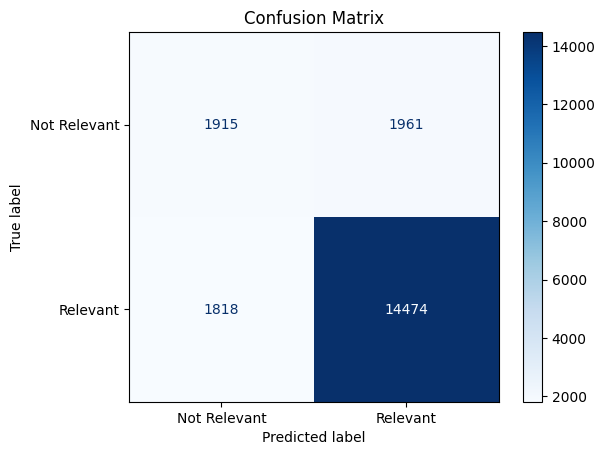

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

threshold = 3.0

y_true = []
y_pred = []

for pred in predictions:

   
    actual = 1 if pred.r_ui >= threshold else 0

   
    predicted = 1 if pred.est >= threshold else 0

    y_true.append(actual)
    y_pred.append(predicted)

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Relevant", "Relevant"]
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

## Evaluation — Content-Based & Hybrid Models

We evaluate CB and Hybrid using the same Precision, Recall, F1 function.


In [37]:
# ── Content-Based Evaluation (Fast) ───────────────────────────
# Build a movieId → index map once (avoid repeated lookups)
movieid_to_idx = {
    row['movieId']: i
    for i, row in movies_content.iterrows()
}

# Build a userId → list of movie indices map once
user_rated_indices = {}
for uid in ratings['userId'].unique():
    movie_ids = ratings[ratings['userId'] == uid]['movieId'].values
    user_rated_indices[uid] = [
        movieid_to_idx[m] for m in movie_ids if m in movieid_to_idx
    ]

# Build CB predictions
cb_predictions = []
for uid, iid, true_r in testset:
    if iid not in movieid_to_idx:
        continue
    target_idx = movieid_to_idx[iid]
    rated_idxs = user_rated_indices.get(uid, [])
    if not rated_idxs:
        continue

    # Key improvement:
    # Get similarity scores between target movie and all rated movies
    sim_scores = cosine_sim[target_idx][rated_idxs]

    # Take only Top-10 similarity scores to improve precision
    top_sim_scores = np.sort(sim_scores)[-10:]

    # Average of best similarities only
    avg_sim = float(top_sim_scores.mean())

    # Convert similarity (0-1) to estimated rating (1-5)
    est = 1 + avg_sim * 4.0
    cb_predictions.append((uid, iid, true_r, est, {}))

p_cb, r_cb, f1_cb = precision__recall__f1(cb_predictions)
print('Content-Based Evaluation (Optimized):')
print(f'  Precision@10 : {p_cb:.4f}')
print(f'  Recall@10    : {r_cb:.4f}')
print(f'  F1-Score@10  : {f1_cb:.4f}')


Content-Based Evaluation (Optimized):
  Precision@10 : 0.7185
  Recall@10    : 0.6337
  F1-Score@10  : 0.6735


In [38]:
# ── Hybrid Evaluation ─────────────────────────────────────────
cf_weight = 0.6
cb_weight = 0.4

cf_map = {(p.uid, p.iid): (p.r_ui, p.est) for p in predictions}
cb_map = {(uid, iid): est for uid, iid, true_r, est, _ in cb_predictions}

hybrid_predictions = []
for (uid, iid), (true_r, cf_est) in cf_map.items():
    cb_est = cb_map.get((uid, iid))
    if cb_est is None:
        continue
    cf_norm    = (cf_est - 1) / 4.0
    cb_norm    = (cb_est - 1) / 4.0
    hybrid_est = 1 + (cf_weight * cf_norm + cb_weight * cb_norm) * 4.0
    hybrid_predictions.append((uid, iid, true_r, hybrid_est, {}))

p_h, r_h, f1_h = precision__recall__f1(hybrid_predictions)
print('Hybrid Evaluation (CF=0.6, CB=0.4):')
print(f'  Precision@10 : {p_h:.4f}')
print(f'  Recall@10    : {r_h:.4f}')
print(f'  F1-Score@10  : {f1_h:.4f}')


Hybrid Evaluation (CF=0.6, CB=0.4):
  Precision@10 : 0.7639
  Recall@10    : 0.6489
  F1-Score@10  : 0.7017


Final Model Comparison:
      Metric  CF (SVD)  CB (TF-IDF)  Hybrid
Precision@10    0.7657       0.7185  0.7639
   Recall@10    0.6505       0.6337  0.6489
       F1@10    0.7035       0.6735  0.7017


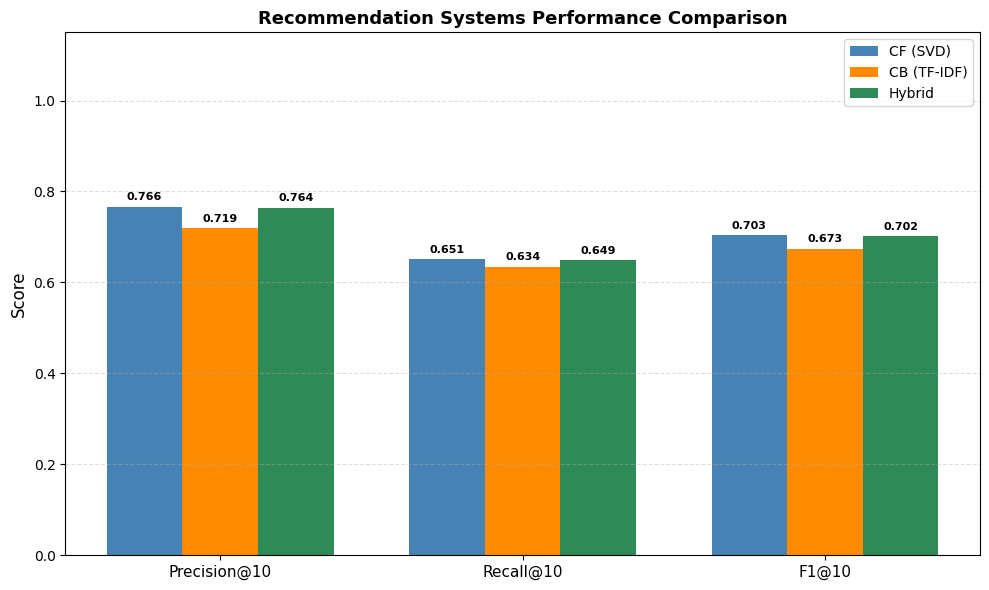

In [39]:
# ── Comparison Table ──────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric'   : ['Precision@10', 'Recall@10', 'F1@10'],
    'CF (SVD)' : [round(p, 4),    round(r, 4),    round(f1, 4)],
    'CB (TF-IDF)': [round(p_cb, 4), round(r_cb, 4), round(f1_cb, 4)],
    'Hybrid'   : [round(p_h, 4),  round(r_h, 4),  round(f1_h, 4)],
})

print("Final Model Comparison:")
print(comparison.to_string(index=False))

# ── Bar Chart Visualization ───────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

x      = np.arange(3)   # 3 metrics: Precision, Recall, F1
width  = 0.25
colors = ['#4682B4', '#FF8C00', '#2E8B57']  # SteelBlue, DarkOrange, SeaGreen
labels = ['CF (SVD)', 'CB (TF-IDF)', 'Hybrid']
data_vals = [
    [p,    r,    f1],      # Collaborative Filtering results
    [p_cb, r_cb, f1_cb],   # Content-Based (optimized) results
    [p_h,  r_h,  f1_h],    # Hybrid results
]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, vals) in enumerate(zip(labels, data_vals)):
    bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i])
    # Add value labels on top of each bar
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(['Precision@10', 'Recall@10', 'F1@10'], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Recommendation Systems Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
